# Quantum Approximate Optimization Algorithm for TSP

### Time Complexity : O(iterations⋅p⋅n^2⋅shots)
*Iterations depend on the optimizer (SPSA).
<br>
p is the number of QAOA layers.
<br>
n^2 is due to the number of qubits required for TSP.
<br>
Shots are the number of quantum circuit executions needed*

In [34]:
import matplotlib.pyplot as plt
import networkx as nx
from itertools import permutations
from qiskit_optimization.applications import Tsp
from qiskit_algorithms import QAOA
from qiskit_algorithms.optimizers import COBYLA
from qiskit_optimization.algorithms import MinimumEigenOptimizer
from qiskit.primitives import Sampler

#### Brute-force 

In [35]:
# Optimized brute-force TSP function with memoization and early termination
def brute_force_tsp(w, N):
    # Generate all permutations of the cities, fixing the first city (0) to reduce permutations.
    a = list(permutations(range(1, N)))
    
    # Initialize the best-known distance as infinity (more explicit than 1e10)
    last_best_distance = float('inf')
    
    # Iterate through each permutation of cities
    for i in a:
        distance = 0
        pre_j = 0  # Start the tour from city 0
        
        # Loop through the current permutation to calculate the total distance
        for j in i:
            distance += w[pre_j, j]  # Accumulate the distance between consecutive cities
            pre_j = j  # Move to the next city
            
            # Early exit if the current distance already exceeds the best-known distance
            if distance >= last_best_distance:
                break
        
        # Add the distance back to the starting city (0) to complete the tour
        distance += w[pre_j, 0]
        order = (0,) + i  # Include the starting city in the tour order
        
        # Update the best-known distance and tour if a shorter one is found
        if distance < last_best_distance:
            best_order = order
            last_best_distance = distance
            print(f"Order = {order} Distance = {distance}")  # More Pythonic string formatting
    
    return last_best_distance, best_order

In [36]:
def draw_graph(G, colors, pos):
    """
    Draws a graph G with specified node colors and positions.

    Parameters:
    G : networkx.Graph
        The graph to be drawn.
    colors : list
        List of colors corresponding to each node.
    pos : dict or list
        A dictionary or list of positions for each node to be used for graph layout.

    Returns:
    None
    """
    # Create axes to draw the graph with a frame
    default_axes = plt.axes(frameon=True)

    # Draw the nodes and edges of the graph with specified node colors and layout positions
    nx.draw_networkx(G, node_color=colors, node_size=600, alpha=0.8, ax=default_axes, pos=pos)

    # Get the weights of the edges (if they exist) and draw them as labels on the edges
    edge_labels = nx.get_edge_attributes(G, "weight")

    # Draw the edge labels on the graph at the specified positions
    nx.draw_networkx_edge_labels(G, pos=pos, edge_labels=edge_labels)

In [37]:
# Generating a random Traveling Salesman Problem (TSP) instance with n cities
n = 4  # Number of cities (nodes)

# Calculate the number of qubits required for QAOA (n^2 for TSP as each city is encoded in binary)
n_qubits = n ** 2

# Generate a random TSP instance with 'n' cities using Qiskit's Tsp application
tsp = Tsp.create_random_instance(n)

# Convert the graph (networkx format) representing the TSP into an adjacency matrix
# The adjacency matrix holds the distances between the cities
adj_matrix = nx.to_numpy_array(tsp.graph)

Distance matrix:
 [[  0.  76.  96.  57.]
 [ 76.   0. 102.  29.]
 [ 96. 102.   0. 112.]
 [ 57.  29. 112.   0.]]


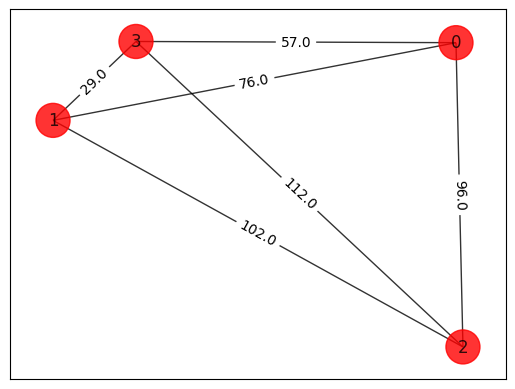

In [38]:
# Print the adjacency matrix, which represents the distance between each pair of cities
print("Distance matrix:\n", adj_matrix)

# Assign colors to nodes (all nodes are colored red in this case)
colors = ["r" for node in tsp.graph.nodes]

# Retrieve the positions of nodes (cities) from the graph for plotting
# Each node has a 'pos' attribute, which defines its x, y coordinates in a 2D space
pos = [tsp.graph.nodes[node]["pos"] for node in tsp.graph.nodes]

# Draw the TSP graph with the specified node colors and positions
# This visually represents the graph with nodes and weighted edges (distances)
draw_graph(tsp.graph, colors, pos)

In [39]:
# Solve the Traveling Salesman Problem (TSP) using brute force to find the optimal tour
# 'adj_matrix' is the distance matrix between cities, and 'n' is the number of cities
best_distance, best_order = brute_force_tsp(adj_matrix, n)

# Print the optimal tour (best_order) and the corresponding total distance (best_distance)
print("Best order from brute force = " + str(best_order) + " with total distance = " + str(best_distance))

Order = (0, 1, 2, 3) Distance = 347.0
Order = (0, 1, 3, 2) Distance = 313.0
Order = (0, 2, 1, 3) Distance = 284.0
Best order from brute force = (0, 2, 1, 3) with total distance = 284.0


In [40]:
# Convert the TSP instance to a Quadratic Unconstrained Binary Optimization (QUBO) problem
# The TSP is reformulated as a QUBO problem using Qiskit's optimization framework
# 'qp' is a QuadraticProgram object that represents the QUBO formulation of the TSP
qp = tsp.to_quadratic_program()

In [57]:
# Initialize the quantum sampler, which will be used to evaluate quantum circuits during optimization
# The sampler is responsible for estimating expectation values of operators during QAOA execution
sampler = Sampler()

# Initialize the COBYLA optimizer, a classical optimizer used to optimize the parameters in QAOA
# 'maxiter=75' specifies that the optimizer will run for a maximum of 75 iterations to find optimal parameters
optimizer = COBYLA(maxiter=60)

C:\Users\anupd\AppData\Local\Temp\ipykernel_13288\1273465867.py:3: DeprecationWarning: The class ``qiskit.primitives.sampler.Sampler`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseSamplerV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Sampler` class is `StatevectorSampler`.
  sampler = Sampler()


In [58]:
# Define the Quantum Approximate Optimization Algorithm (QAOA) instance
# The QAOA algorithm is used to solve combinatorial optimization problems by finding approximate solutions
# 'sampler' is responsible for executing quantum circuits and obtaining measurement results
# 'optimizer' is used to adjust the parameters of the quantum circuit to minimize the cost function
qaoa = QAOA(sampler=sampler, optimizer=optimizer)

In [59]:
# Setup the MinimumEigenOptimizer using the QAOA algorithm
# MinimumEigenOptimizer is a class that leverages a quantum algorithm to find the minimum eigenvalue of a Hamiltonian
# 'qaoa' is the quantum algorithm (QAOA) used to estimate the eigenvalues and optimize the problem
optimizer_qaoa = MinimumEigenOptimizer(min_eigen_solver=qaoa)

In [60]:
# Solve the QUBO problem using the MinimumEigenOptimizer with QAOA
# The 'qp' object is a QuadraticProgram representing the QUBO formulation of the problem
# The 'solve' method applies the QAOA algorithm to find the optimal solution to the QUBO problem
result = optimizer_qaoa.solve(qp)

# Print the result of the optimization
# 'result' contains the optimal solution found by the QAOA algorithm, including the objective value and the optimal variable values
print(result.prettyprint())

objective function value: 284.0
variable values: x_0_0=0.0, x_0_1=0.0, x_0_2=0.0, x_0_3=1.0, x_1_0=0.0, x_1_1=1.0, x_1_2=0.0, x_1_3=0.0, x_2_0=0.0, x_2_1=0.0, x_2_2=1.0, x_2_3=0.0, x_3_0=1.0, x_3_1=0.0, x_3_2=0.0, x_3_3=0.0
status: SUCCESS
